# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [6]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [7]:
def plot_audio_seg(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)

    ax = plt.gca()
    if len(plot_dets)>0:
        plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
        for i, row in plot_dets.iterrows():
            rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                            (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                            linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
            ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 256e3/fs, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 6), 
               labels=np.linspace(0, duration, 6, dtype=plot_xtype), rotation=0)
    plt.xlabel("Time (s)")
    plt.twinx(ax=ax)
    plt.yticks(ticks=np.linspace(0, 256e3/fs, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.ylim(0, 256e3/fs)

    plt.show()

In [8]:
def convert_nabatdf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] =  (df['peak_time_ms']-50)/1000
    raven_df['End Time (s)'] = (df['peak_time_ms']-40)/1000
    raven_df['Low Freq (Hz)'] = df['peak_freq_hz']-2000
    raven_df['High Freq (Hz)'] = df['peak_freq_hz']+2000
    raven_df['prediction'] = df['prediction']
    raven_df['score'] = df['score']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_nabatdf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = (df['peak_time_ms']-50)/1000
    bd2_df['end_time'] = (df['peak_time_ms']-40)/1000
    bd2_df['low_freq'] = df['peak_freq_hz']-2000
    bd2_df['high_freq'] = df['peak_freq_hz']+2000
    bd2_df['prediction'] = df['prediction']
    bd2_df['score'] = df['score']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_kaleidoscopedf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] = df['OFFSET']
    raven_df['End Time (s)'] = df['OFFSET'] + df['DURATION']
    raven_df['Low Freq (Hz)'] = df['Fmin']
    raven_df['High Freq (Hz)'] = df['Fmax']
    raven_df['input_file'] = df['IN FILE']
    raven_df['input_dir'] = df['INDIR']
    raven_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        raven_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        raven_df['TOP1MATCH'] = df['TOP1MATCH']
    raven_df['TOP1DIST'] = df['TOP1DIST']
    raven_df['TOP2MATCH'] = df['TOP2MATCH']
    raven_df['TOP2DIST'] = df['TOP2DIST']
    raven_df['TOP3MATCH'] = df['TOP3MATCH']
    raven_df['TOP3DIST'] = df['TOP3DIST']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET']
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION']
    bd2_df['low_freq'] = df['Fmin']
    bd2_df['high_freq'] = df['Fmax']
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_raventxtdf_to_bd2df(raventxt_df):
    bd2_human_df = raventxt_df[1::2].copy()
    bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB',
                                'Delta Time (s)':'delta_time_s'}, inplace=True)
    bd2_human_df.sort_values('start_time', inplace=True)
    
    return bd2_human_df

def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [9]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
#  '20210910_030000':'Foliage'}
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [10]:
wav_filename = '20220826_070000'
site = file_sites[wav_filename]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

raventxt_human_df = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}.txt', sep='\t')
bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
bd2_human_df.reset_index(inplace=True, drop=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF
...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF


In [11]:
len(bd2_human_df[bd2_human_df['freq_group']=='LF'])

1138

In [12]:
len(bd2_human_df[bd2_human_df['freq_group']=='HF'])

3268

In [13]:
bd2_human_df

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF
...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF


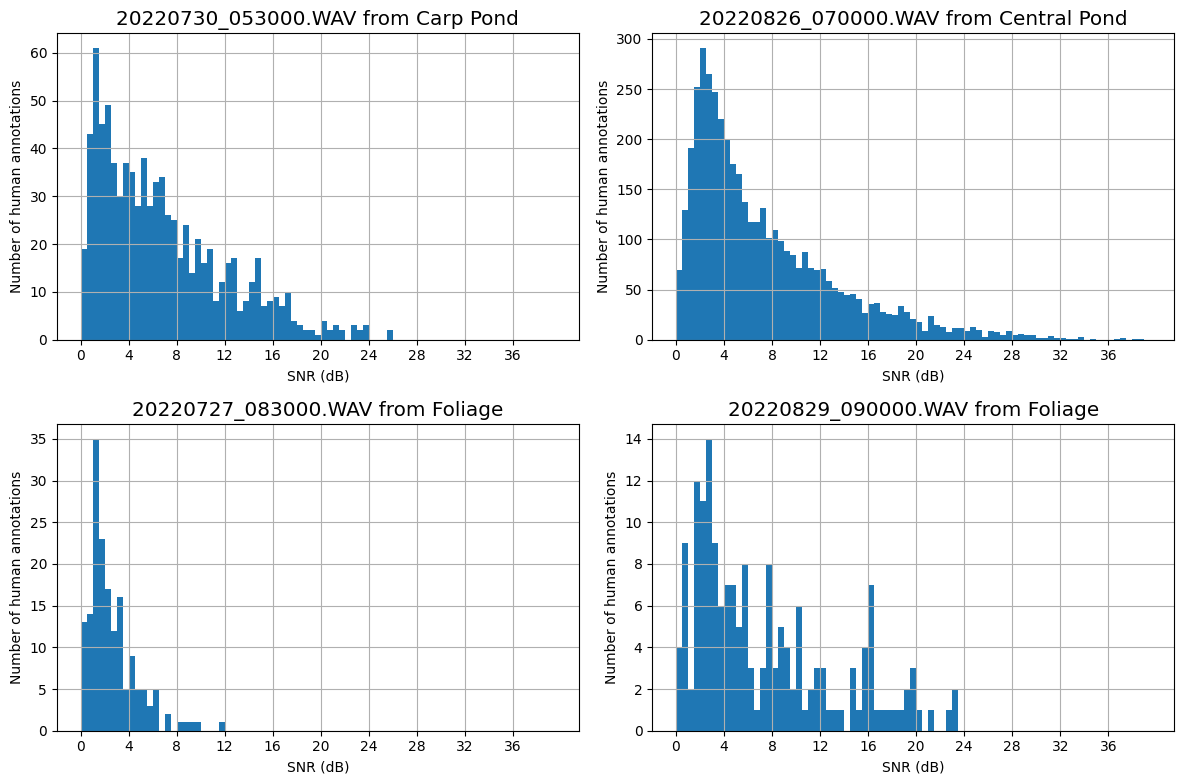

In [14]:
fig, ax = plt.subplots(2,2,figsize=(12,8))
plt.rcParams.update({'font.size':12})
easy_ax = ax.flatten()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    raventxt_human_df = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}{extension}', sep=sep)
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
    bd2_human_df.reset_index(inplace=True, drop=True)

    audio_file = sf.SoundFile(plot_file)
    fs = audio_file.samplerate
    nyquist = fs/2
    call_snrs = []
    for i, row in bd2_human_df.iterrows():
        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)

        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]

        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)
        call_snrs.append(snr)

    bd2_human_df['adityas_method_snr_dB'] = call_snrs
    snr_included_ravenpro_human_txt = convert_bd2df_ravenpro(bd2_human_df)
    snr_included_ravenpro_human_txt.to_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep, index=False)

    bd2_human_df['adityas_method_snr_dB'].hist(bins=np.arange(0, 40, 0.5), ax=easy_ax[file_num])
    easy_ax[file_num].set_title(f'{wav_filename}.WAV from {SITE_NAMES[site]}')
    easy_ax[file_num].set_xticks(np.arange(0, 40, 4))
    easy_ax[file_num].set_xlabel('SNR (dB)')
    easy_ax[file_num].set_ylabel('Number of human annotations')

fig.tight_layout()
plt.show()

In [15]:
def get_section_of_call_in_file(detection, audio_file):
    fs = audio_file.samplerate
    num_frames = audio_file.frames
    file_length = num_frames/fs

    call_dur = (detection['end_time'] - detection['start_time'])
    pad = min(min(detection['start_time'] - call_dur, file_length - detection['end_time']), 0.006) / 3
    start = detection['start_time'] - call_dur - (3*pad)
    duration = ((2 * call_dur) + (4*pad))

    try:
        audio_file.seek(int(fs*start))
        audio_seg = audio_file.read(int(fs*duration))
        length_of_section = call_dur + (2*pad)
    except sf.LibsndfileError as e:
        print(f'Start time : {start} invalid, detection starts at {detection["start_time"]} in segment:{audio_file.name}')
        audio_seg = None
        length_of_section = 0

    return audio_seg, length_of_section, pad

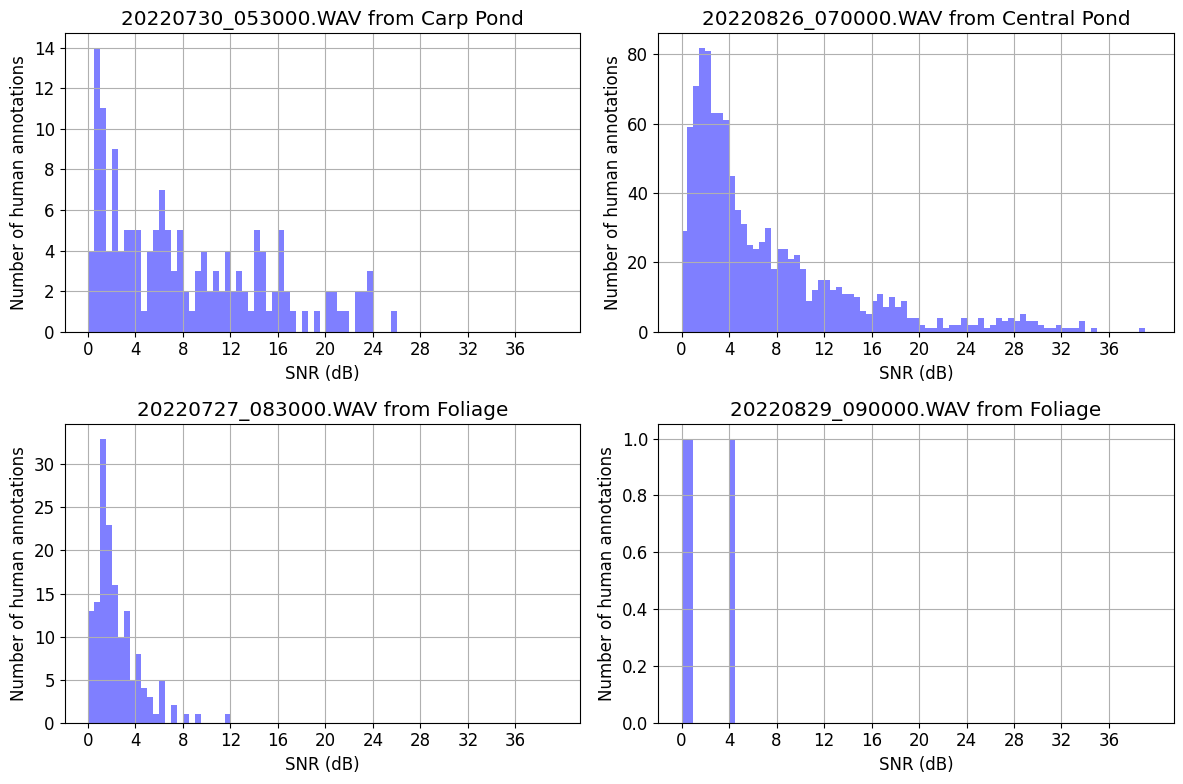

In [16]:
fig, ax = plt.subplots(2,2,figsize=(12,8))
plt.rcParams.update({'font.size':12})
easy_ax = ax.flatten()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    raventxt_human_df = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}{extension}', sep=sep)
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
    bd2_human_df.reset_index(inplace=True, drop=True)

    audio_file = sf.SoundFile(plot_file)
    fs = audio_file.samplerate
    nyquist = fs/2
    call_snrs = []
    peak_freqs_spec = []
    peak_freq_times_spec = []
    for i, row in bd2_human_df.iterrows():
        call_dur = (row['end_time'] - row['start_time'])
        audio_seg, length_of_section, pad = get_section_of_call_in_file(row, audio_file)
        seg_start = row['start_time'] - call_dur - (3*pad)

        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)

        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal_for_peaks = band_limited_audio_seg.copy()
        signal_for_peaks[:int(fs*(length_of_section+pad))] = 0
        signal_for_peaks[-int(fs*pad):] = 0
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(256))
        f, t, Sxx = scipy.signal.spectrogram(signal_for_peaks, fs, detrend=False,
                                    nfft=256, 
                                    window=mpl_specgram_window)
        plt_Sxx = 10*np.log10(Sxx)
        max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]
        peak_freqs_spec.append(peak_freq[0])
        peak_freq_times_spec.append(seg_start+peak_freq_time[0])

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]

        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)
        call_snrs.append(snr)

    bd2_human_df['adityas_method_snr_dB'] = call_snrs
    bd2_human_df['peak_frequency_time'] = peak_freq_times_spec
    snr_included_ravenpro_human_txt = convert_bd2df_ravenpro(bd2_human_df)
    snr_included_ravenpro_human_txt.to_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep, index=False)

    lf_bd2_human_df = bd2_human_df[bd2_human_df['freq_group']=="LF"].copy()
    lf_bd2_human_df['adityas_method_snr_dB'].hist(bins=np.arange(0, 40, 0.5), color='blue', alpha=0.5, ax=easy_ax[file_num])
    easy_ax[file_num].set_title(f'{wav_filename}.WAV from {SITE_NAMES[site]}')
    easy_ax[file_num].set_xticks(np.arange(0, 40, 4))
    easy_ax[file_num].set_xlabel('SNR (dB)')
    easy_ax[file_num].set_ylabel('Number of human annotations')

fig.tight_layout()
plt.show()

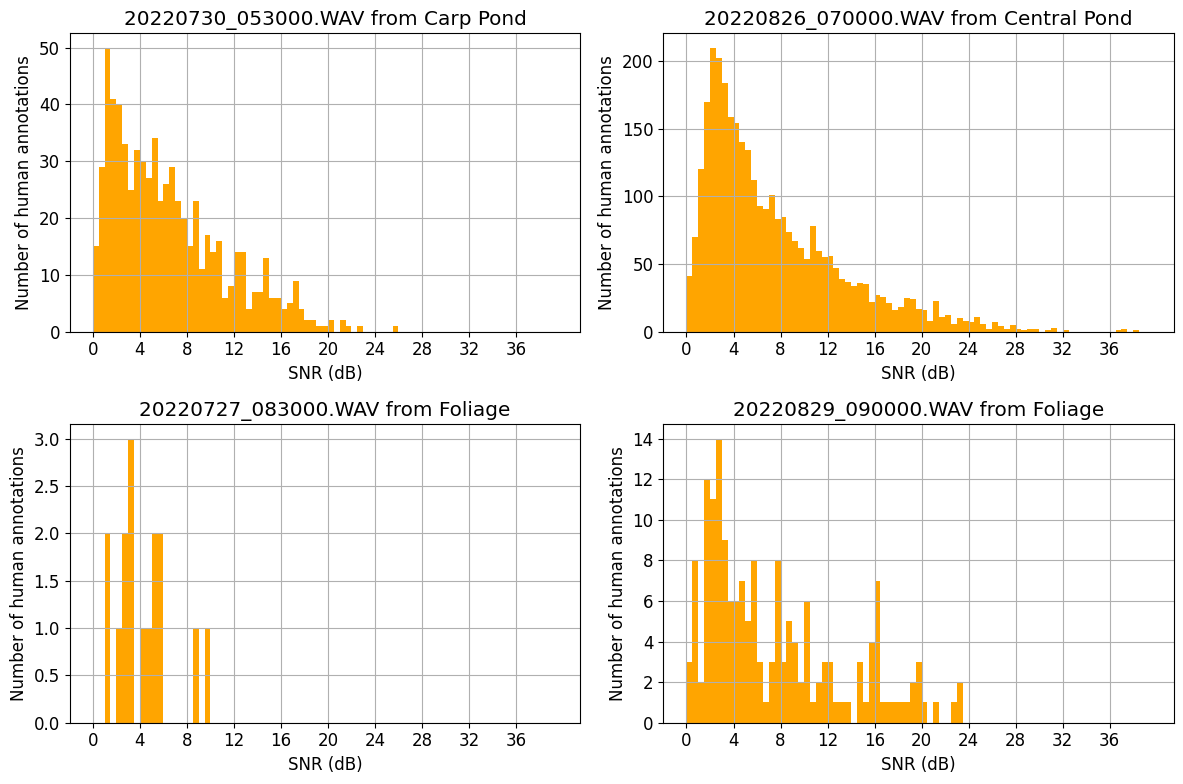

In [17]:
fig, ax = plt.subplots(2,2,figsize=(12,8))
plt.rcParams.update({'font.size':12})
easy_ax = ax.flatten()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    raventxt_human_df = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}{extension}', sep=sep)
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
    bd2_human_df.reset_index(inplace=True, drop=True)

    audio_file = sf.SoundFile(plot_file)
    fs = audio_file.samplerate
    nyquist = fs/2
    call_snrs = []
    peak_freqs_spec = []
    peak_freq_times_spec = []
    for i, row in bd2_human_df.iterrows():
        call_dur = (row['end_time'] - row['start_time'])
        audio_seg, length_of_section, pad = get_section_of_call_in_file(row, audio_file)
        seg_start = row['start_time'] - call_dur - (3*pad)

        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)

        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal_for_peaks = band_limited_audio_seg.copy()
        signal_for_peaks[:int(fs*(length_of_section+pad))] = 0
        signal_for_peaks[-int(fs*pad):] = 0
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(256))
        f, t, Sxx = scipy.signal.spectrogram(signal_for_peaks, fs, detrend=False,
                                    nfft=256, 
                                    window=mpl_specgram_window)
        plt_Sxx = 10*np.log10(Sxx)
        max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]
        peak_freqs_spec.append(peak_freq[0])
        peak_freq_times_spec.append(seg_start+peak_freq_time[0])

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]

        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)
        call_snrs.append(snr)

    bd2_human_df['adityas_method_snr_dB'] = call_snrs
    bd2_human_df['peak_frequency_time'] = peak_freq_times_spec
    snr_included_ravenpro_human_txt = convert_bd2df_ravenpro(bd2_human_df)
    snr_included_ravenpro_human_txt.to_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep, index=False)

    hf_bd2_human_df = bd2_human_df[bd2_human_df['freq_group']=="HF"].copy()
    hf_bd2_human_df['adityas_method_snr_dB'].hist(bins=np.arange(0, 40, 0.5), color='orange', ax=easy_ax[file_num])
    easy_ax[file_num].set_title(f'{wav_filename}.WAV from {SITE_NAMES[site]}')
    easy_ax[file_num].set_xticks(np.arange(0, 40, 4))
    easy_ax[file_num].set_xlabel('SNR (dB)')
    easy_ax[file_num].set_ylabel('Number of human annotations')

fig.tight_layout()
plt.show()

In [18]:
wav_filename = '20220826_070000'
site = 'Central'
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

In [19]:
snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
bd2_human_df = snr_included_ravenpro_human_txt.copy()
bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df.sort_values('start_time', inplace=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF,2.567162
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF,6.879404
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF,7.902035
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF,1.782390
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF,1.514990
...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF,9.656562
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF,6.562988
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF,5.589297
